In [13]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import numpy as np

simulator = AerSimulator()


Total count for 00 and 11 are: {'11': 506, '00': 494}


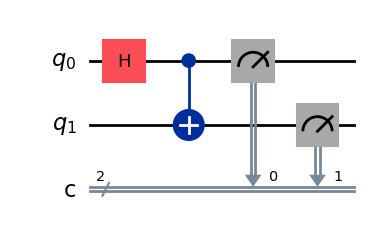

In [3]:

# Create a Quantum Circuit acting on the q register
circuit = QuantumCircuit(2, 2)

# Add a H gate on qubit 0
circuit.h(0)

# Add a CX (CNOT) gate on control qubit 0 and target qubit 1
circuit.cx(0, 1)

# Map the quantum measurement to the classical bits
circuit.measure([0, 1], [0, 1])

# Compile the circuit for the support instruction set (basis_gates)
# and topology (coupling_map) of the backend
compiled_circuit = transpile(circuit, simulator)

# Execute the circuit on the aer simulator
job = simulator.run(compiled_circuit, shots=1000)

# Grab results from the job
result = job.result()

# Returns counts
counts = result.get_counts(compiled_circuit)
print("\nTotal count for 00 and 11 are:", counts)

# Draw the circuit
circuit.draw("mpl")

Result(backend_name='aer_simulator', backend_version='0.17.2', qobj_id='', job_id='6ed513b1-cdd8-470c-b42e-c438941a1ac8', success=True, results=[ExperimentResult(shots=1000, success=True, meas_level=2, data=ExperimentResultData(counts={'0x1': 481, '0x0': 519}), header=QobjExperimentHeader(creg_sizes=[['c', 1]], global_phase=0.0, memory_slots=1, n_qubits=1, name='circuit-166', qreg_sizes=[['q', 1]], metadata={}), status=DONE, seed_simulator=1322632369, metadata={'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 1, 'num_clbits': 1, 'time_taken': 0.0031476, 'sample_measure_time': 0.0012146, 'input_qubit_map': [[0, 0]], 'max_memory_mb': 7564, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 6, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}, time_taken=0.0031476)], date=2025-10-20T06:11:29.1189

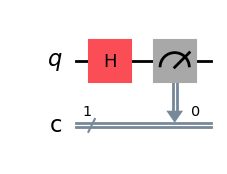

In [4]:

circuit = QuantumCircuit(1, 1)

circuit.h(0)

circuit.measure([0], [0])

compiled_circuit = transpile(circuit, simulator)

result = simulator.run(compiled_circuit, shots=1000).result()
counts = result.get_counts(compiled_circuit)
print(result)
print(counts)

circuit.draw("mpl")

x, ['x[0]', 'x[1]', 'x[2]', 'x[3]']
w, ['w[0]', 'w[1]', 'w[2]', 'w[3]', 'w[4]', 'w[5]', 'w[6]', 'w[7]', 'w[8]', 'w[9]']


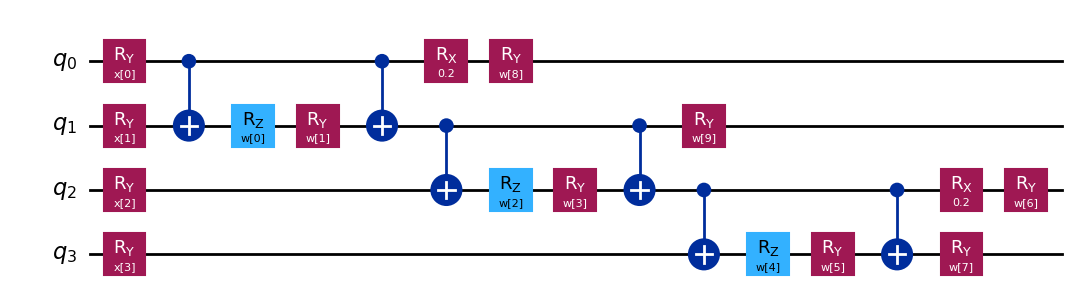

In [12]:
num_qubits = 4
conv_layers = 1

# input parameters (angle encodings)
input_params = ParameterVector('x', length=num_qubits)
print(input_params)

# trainable parameters (we'll use a small set)
# for each conv layer we have parameterized rotations on each qubit and two-qubit entanglers
w_len = conv_layers * (num_qubits * 1 + (num_qubits - 1) * 2)  # rough
weight_params = ParameterVector('w', length=w_len)
print(weight_params)

qc = QuantumCircuit(num_qubits)

# Encoding
for i in range(num_qubits):
    qc.ry(input_params[i], i)

# Parameter indexing helper
idx = 0
for layer in range(conv_layers):
    # local single-qubit rotations (like convolution bias)
    #for q in range(num_qubits):
    #    qc.ry(weight_params[idx], q); idx += 1

    # local entangling blocks (two-qubit unitaries between neighbors)
    # use CNOT + rotations + CNOT to make a controlled-Ry-like entangler
    for q in range(num_qubits - 1):
        qc.cx(q, q + 1)
        qc.rz(weight_params[idx], q + 1); idx += 1
        qc.ry(weight_params[idx], q + 1); idx += 1
        qc.cx(q, q + 1)

    # small "pooling-like" rotation (single-qubit)
    for q in range(0, num_qubits, 2):  # on qubits 0 and 2 (reduce locality)
        qc.rx(0.2, q)  # small fixed rotation (non-learned) to mix info
# final local rotations (ensure idx consumed safely; if any leftover params, attach them)
while idx < len(weight_params):
    qc.ry(weight_params[idx], idx % num_qubits)
    idx += 1
qc.draw("mpl")

Result(backend_name='aer_simulator', backend_version='0.17.2', qobj_id='', job_id='743be8ed-530d-40cb-994c-be4962b7f1d5', success=True, results=[ExperimentResult(shots=1000, success=True, meas_level=2, data=ExperimentResultData(counts={'0x0': 387, '0x1': 613}), header=QobjExperimentHeader(creg_sizes=[['c', 1]], global_phase=0.23616921147610692, memory_slots=1, n_qubits=4, name='circuit-182', qreg_sizes=[['q', 4]], metadata={}), status=DONE, seed_simulator=3222424838, metadata={'batched_shots_optimization': False, 'required_memory_mb': 1, 'method': 'statevector', 'active_input_qubits': [0, 1, 2, 3], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 4, 'num_clbits': 1, 'time_taken': 0.002175, 'sample_measure_time': 0.000493, 'input_qubit_map': [[0, 0], [1, 1], [2, 2], [3, 3]], 'max_memory_mb': 7564, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 6, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': True, 'thresho

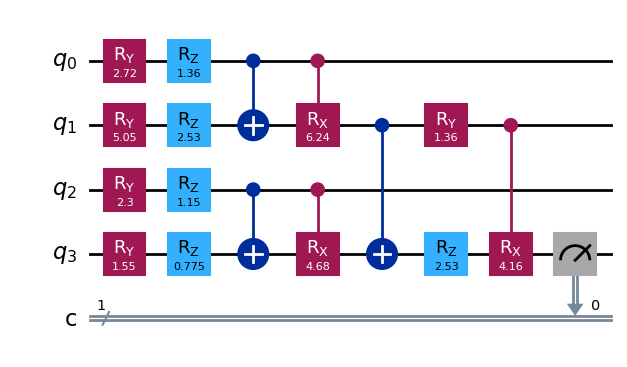

In [ ]:
def qcnn_layer(theta_conv, theta_pool):
    """
    Builds a small 4→1 QCNN with controlled-Rx pooling.
    
    Args:
        theta_conv: list of rotation parameters for convolution layers
        theta_pool: list of rotation parameters for pooling layers
    Returns:
        QuantumCircuit object
    """
    qc = QuantumCircuit(4, 1)

    # --- Step 1: Convolution layer ---
    # Apply local rotations + entanglement between neighboring qubits
    for i in range(4):
        qc.ry(theta_conv[i], i)
        qc.rz(theta_conv[i] / 2, i)
    for i in range(0, 4, 2):
        qc.cx(i, i+1)  # entangle neighboring pairs

    # --- Step 2: Pooling layer 1 (4 → 2) ---
    qc.crx(theta_pool[0], 0, 1)
    qc.crx(theta_pool[1], 2, 3)
    # Discard pooled qubits (simulate pooling by not using 0,2 anymore)

    # --- Step 3: Convolution on remaining qubits (1,3) ---
    qc.cx(1, 3)
    qc.ry(theta_conv[0]/2, 1)
    qc.rz(theta_conv[1]/2, 3)

    # --- Step 4: Pooling layer 2 (2 → 1) ---
    qc.crx(theta_pool[2], 1, 3)
    # Measure the final pooled qubit
    qc.measure(3, 0)
    compiled_circuit = transpile(qc, simulator)

    result = simulator.run(compiled_circuit, shots=1000).result()
    counts = result.get_counts(compiled_circuit)
    print(result)
    print(counts)   
    return qc


# Example parameters
#theta_conv = np.random.uniform(0, 2*np.pi, 4)
pi = np.pi
theta_conv = [0, 2 * pi / 3, 4 * pi/ 3, 2 * pi]
#theta_pool = np.random.uniform(0, 2*np.pi, 3)
theta_pool

qc = qcnn_layer(theta_conv, theta_pool)
qc.draw('mpl')